# Dataset Description
## Domestic Violence 2015-2024 segregated

**Cases**: Instituto Nacional de Medicina Legal y Ciencias Forenses, Bogotá D.C. [Download](https://www.datos.gov.co/Justicia-y-Derecho/Violencia-intrafamiliar-Colombia-a-os-2015-a-2024-/ers2-kerr/about_data)

**Population**: DANE, [download](https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion)

# Code
## Imports

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [23]:
path_cases = "./data/Violencia_intrafamiliar._Colombia,_años_2015_a_2024._Cifras_definitivas_20260815.csv"
path_pop = "./data/nacional.csv"

cases_cols = [
    "Año del hecho", 
    "Sexo de la victima", 
    "Grupo de edad quinquenal", 
    "Factor Desencadenante de la Agresión", 
    "Presunto Agresor Detallado"
]

cases = pd.read_csv(path_cases, encoding="utf-8", usecols=cases_cols)
pop = pd.read_csv(path_pop, encoding="utf-8", usecols=["AÑO", "Total Hombres", "Total Mujeres"])

## Clean data gender

In [24]:
cases["Casos"] = 1

gender = cases.groupby(["Año del hecho", "Sexo de la victima"]).sum(numeric_only=True).reset_index()
female = gender[gender["Sexo de la victima"].str.lower().eq("mujer")]
male = gender[gender["Sexo de la victima"].str.lower().eq("hombre")]

male_g = pd.merge(
    male, 
    pop, 
    left_on="Año del hecho", 
    right_on="AÑO", 
    how="left"
)[["Año del hecho", "Casos", "Total Hombres"]]

female_g = pd.merge(
    female, 
    pop, 
    left_on="Año del hecho", 
    right_on="AÑO", 
    how="left"
)[["Año del hecho", "Casos", "Total Mujeres"]]

male_g["Ratio"] = (male_g["Casos"] / male_g["Total Hombres"]) * 100000
female_g["Ratio"] = (female_g["Casos"] / female_g["Total Mujeres"]) * 100000

## Plot gender

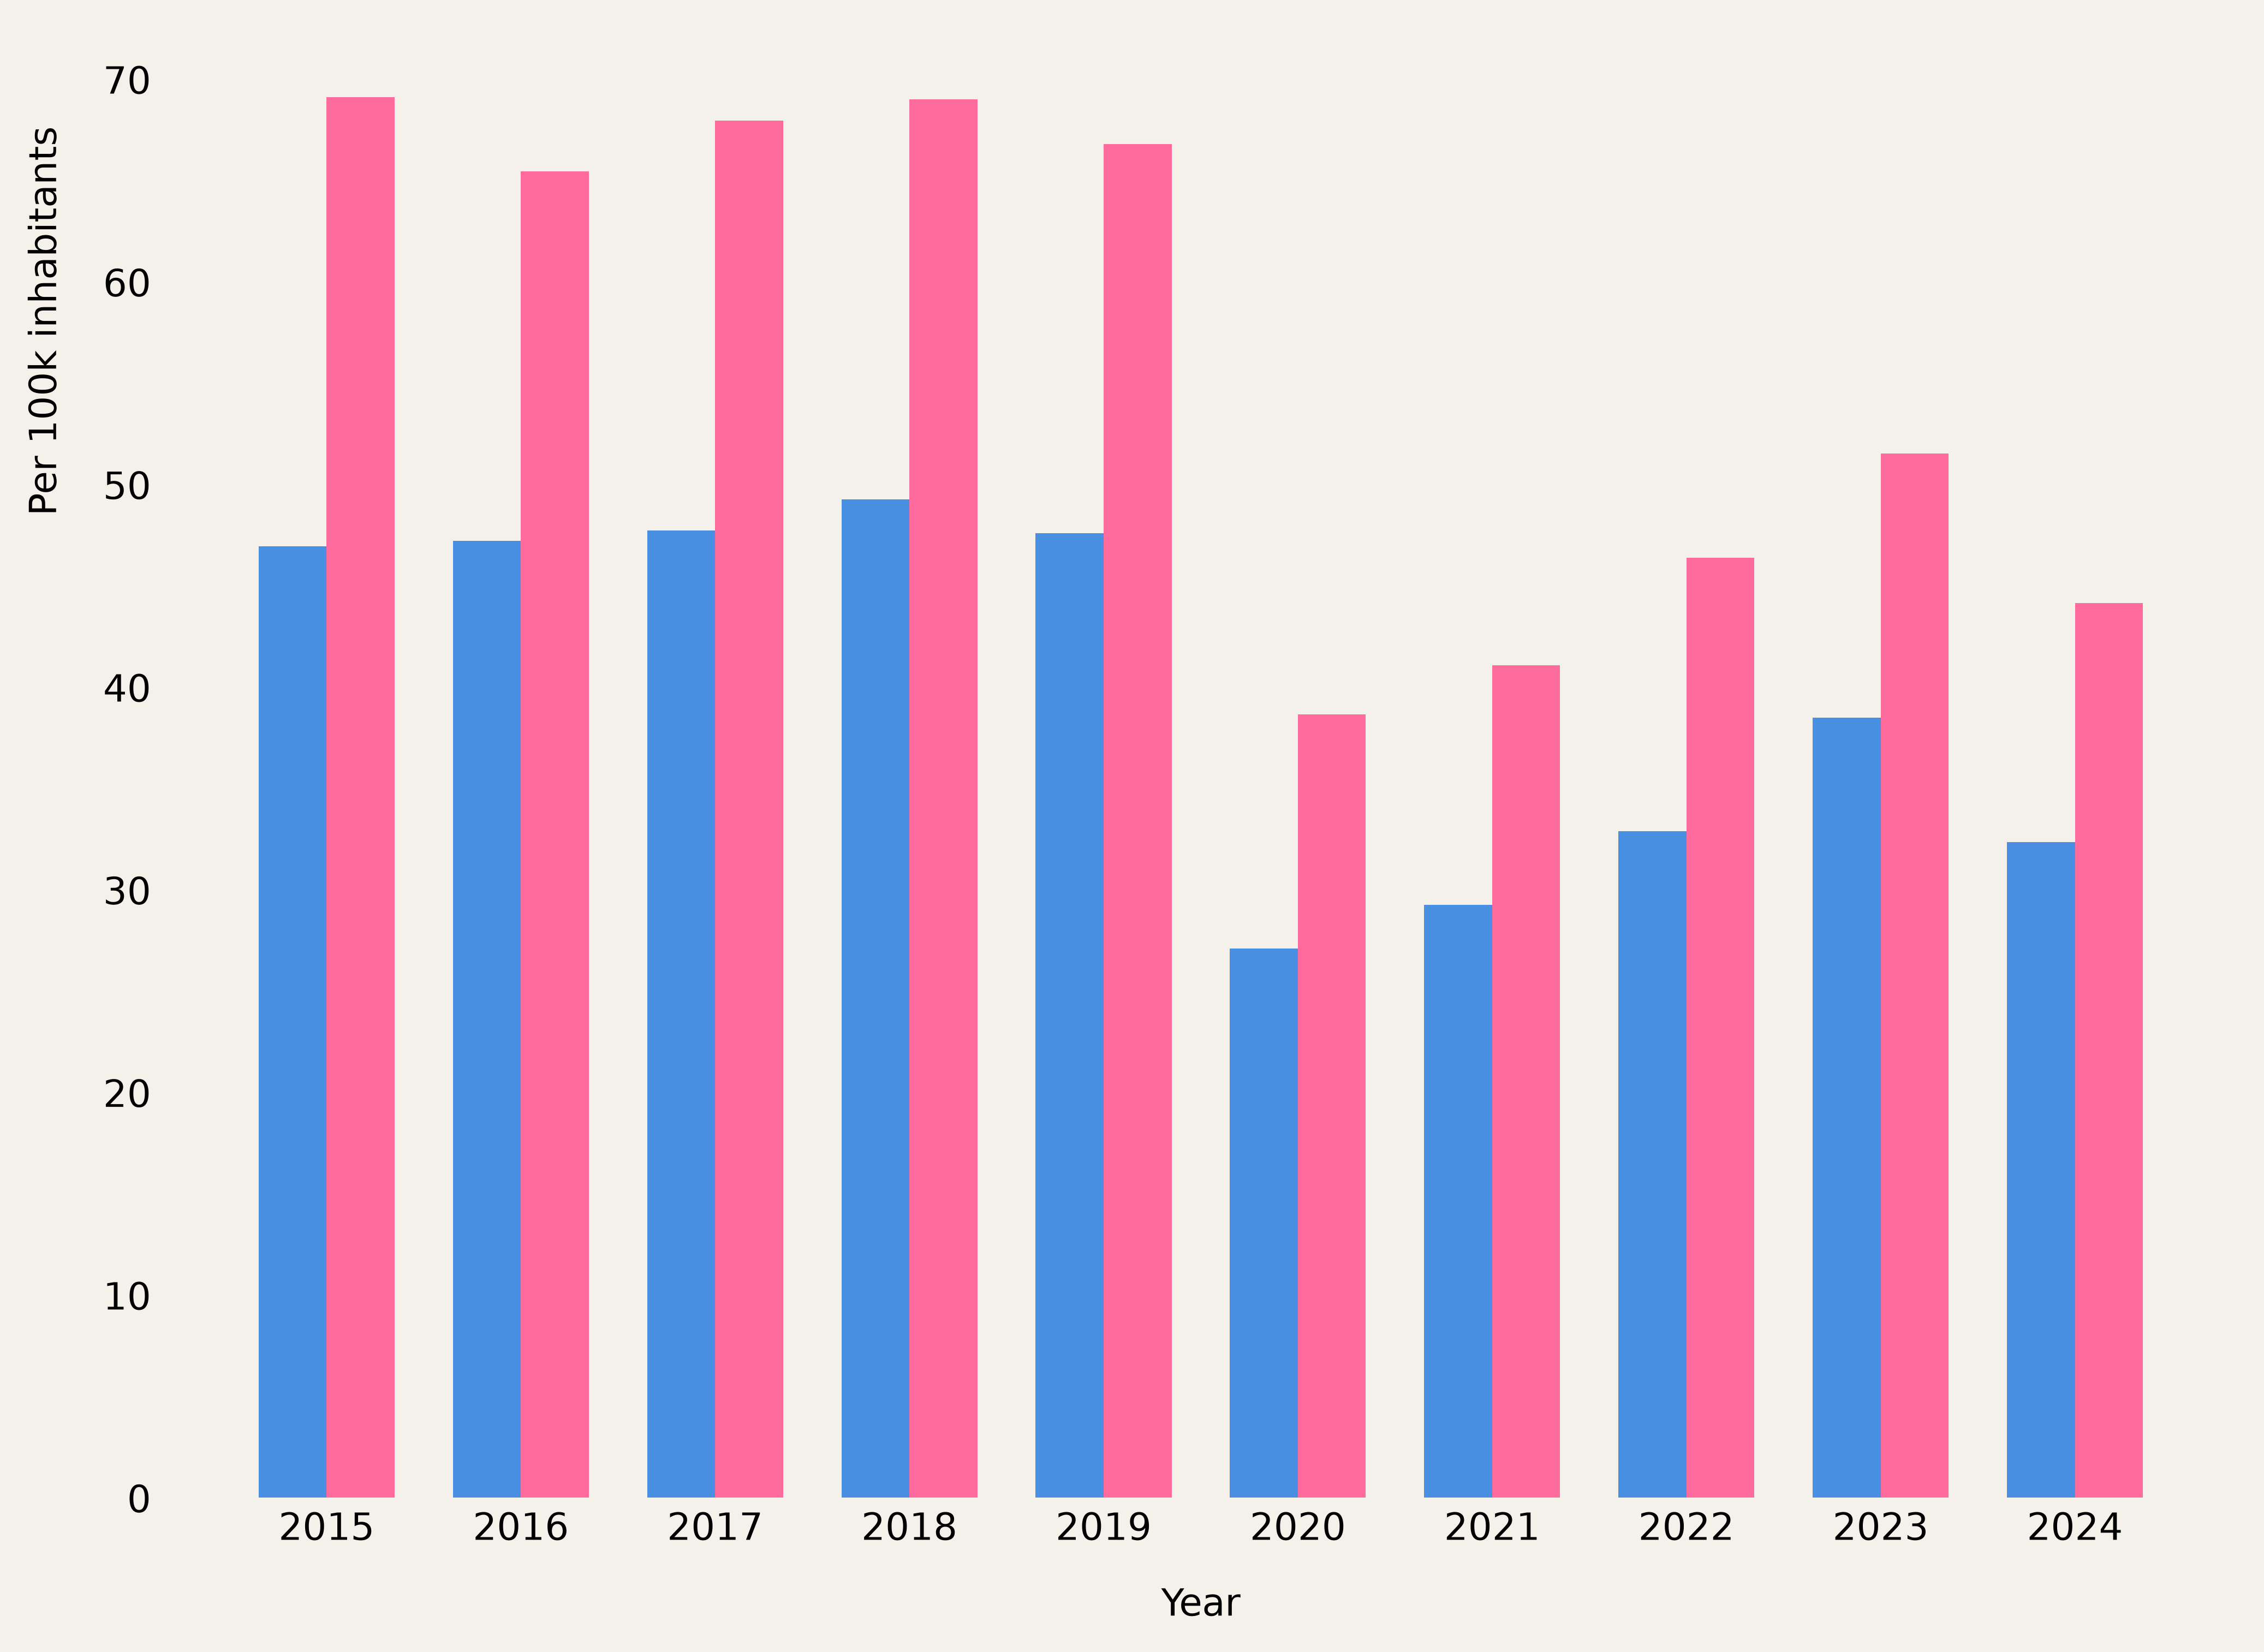

In [25]:
background = "#F4F1EA"
women_color = "#FF6B9D"
men_color = "#4a90e2"
x_axis = male_g["Año del hecho"]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

width = 0.35
x = range(len(x_axis))

plt.bar([i - width/2 for i in x], male_g["Ratio"], width=width, color=men_color, label="Male")
plt.bar([i + width/2 for i in x], female_g["Ratio"], width=width, color=women_color, label="Female")

plt.xticks(ticks=x, labels=x_axis)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Per 100k inhabitants", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()

## Clean data Age

In [26]:
def clean(tmp):
    tmp["Grupo de edad quinquenal"] = tmp["Grupo de edad quinquenal"].str.replace(r"[()]", "", regex=True)
    tmp.drop(18, inplace=True)
    tmp["Grupo de edad quinquenal"] = tmp["Grupo de edad quinquenal"].str.replace("80 y más", "80+")
    tmp["Grupo de edad quinquenal"] = tmp["Grupo de edad quinquenal"].str.replace(" a ", "-")

    return tmp

def grouping(df):
    grouped = (df
       .groupby("Grupo de edad quinquenal")
       .sum(numeric_only=True)
       .reset_index()[["Grupo de edad quinquenal", "Casos"]]
    )

    return grouped

women = (cases[
         cases["Sexo de la victima"].str.lower().eq("mujer")][["Grupo de edad quinquenal", "Casos"]
         ]
)
men = (cases[
       cases["Sexo de la victima"].str.lower().eq("hombre")][["Grupo de edad quinquenal", "Casos"]
       ]
)

women_cases = grouping(women)
men_cases = grouping(men) 

women_cases = clean(women_cases)
men_cases = clean(men_cases)

## Plot ages

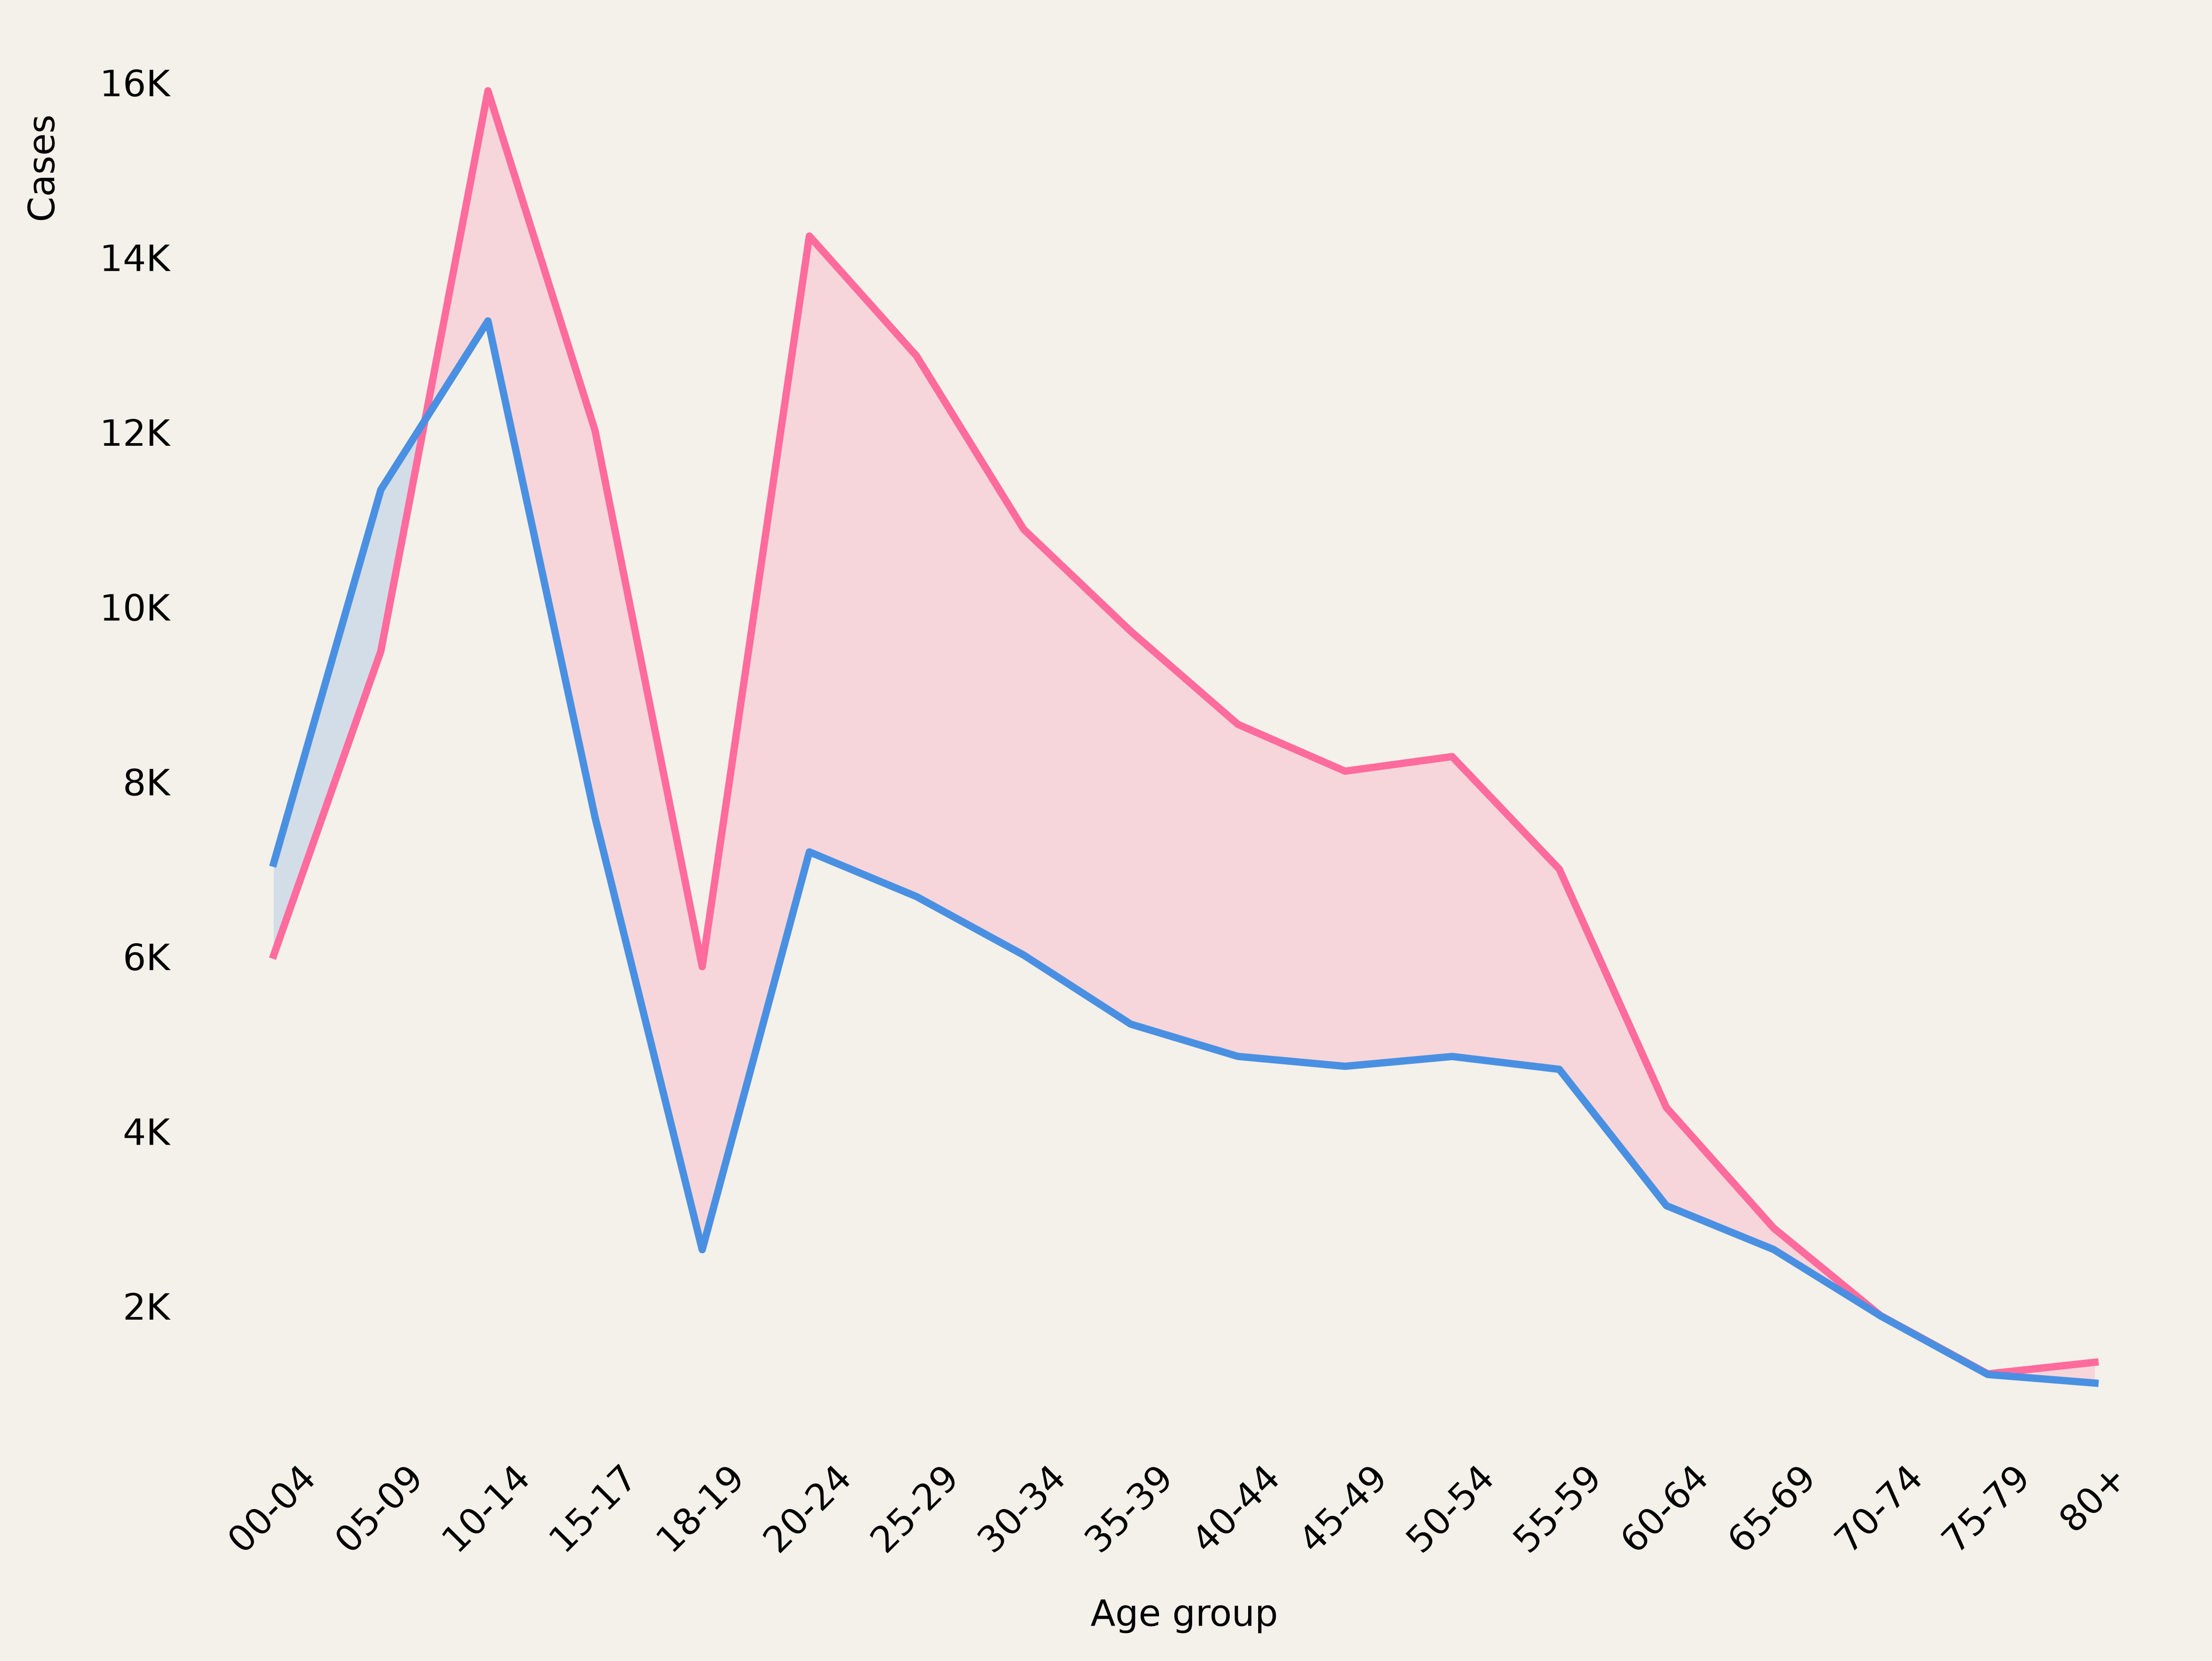

In [27]:
x = women_cases["Grupo de edad quinquenal"]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(x, women_cases["Casos"], color=women_color, linewidth=2)
plt.plot(x, men_cases["Casos"], color=men_color, linewidth=2)

plt.fill_between(
    x=x, 
    y1=women_cases["Casos"], 
    y2=men_cases["Casos"], 
    where=(women_cases["Casos"] > men_cases["Casos"]), 
    interpolate=True, 
    facecolor=women_color,
    alpha=0.2
)

plt.fill_between(
    x=x, 
    y1=women_cases["Casos"], 
    y2=men_cases["Casos"], 
    where=(women_cases["Casos"] < men_cases["Casos"]), 
    interpolate=True, 
    facecolor=men_color,
    alpha=0.2
)

plt.xticks(x, rotation=45)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Cases", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Age group", labelpad=10, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

plt.show()

## Extra Information

In [28]:
cases["Factor Desencadenante de la Agresión"] = (cases["Factor Desencadenante de la Agresión"]
                                                 .str.normalize("NFKD")
                                                 .str.encode("ascii", errors="ignore")
                                                 .str.decode("utf-8")
                                                 )
causes = (cases
          .groupby("Factor Desencadenante de la Agresión")
          .sum(numeric_only=True)
          .reset_index()
)[["Factor Desencadenante de la Agresión", "Casos"]]

combined_alcohol = causes.loc[causes["Factor Desencadenante de la Agresión"].isin([
    "Alcoholismo / drogadiccion",
    "Consumo de alcohol y/o sustancias psicoactivas"
]), "Casos"].sum()

combined_otras = causes.loc[causes["Factor Desencadenante de la Agresión"].isin([
    "Otras",
    "Otras razones"
]), "Casos"].sum()

causes = causes[~causes["Factor Desencadenante de la Agresión"].isin([
    "Alcoholismo / drogadiccion",
    "Consumo de alcohol y/o sustancias psicoactivas",
    "Otras",
    "Otras razones"
])]

causes = pd.concat([causes, pd.DataFrame([
    {"Factor Desencadenante de la Agresión": "Alcoholismo / drogadiccion", "Casos": combined_alcohol},
    {"Factor Desencadenante de la Agresión": "Otras",                      "Casos": combined_otras}
])], ignore_index=True)

top_causes = causes.nlargest(columns="Casos", n=6)

In [29]:
cases["Presunto Agresor Detallado"] = (cases["Presunto Agresor Detallado"]
                                       .str.replace(" ", "")
                                       .str.lower()
                                       .str.normalize("NFKD")
                                       .str.encode("ascii", errors="ignore")
                                       .str.decode("utf-8")
                                       )
person = (
    cases
    .groupby("Presunto Agresor Detallado")
    .sum(numeric_only=True)
    .reset_index()
)[["Presunto Agresor Detallado", "Casos"]]

top_person = person.nlargest(columns="Casos", n=5)